In [3]:
import sys
print(sys.version)
print(sys.executable)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
c:\Users\olaaz\AppData\Local\Python\pythoncore-3.13-64\python.exe


In [4]:
%pip install numpy pandas matplotlib seaborn scikit_learn scipy jupyter

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached notebook-7.6.2-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.6.3-py3-none-any.whl.metadata (16 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

1. Model = wx + b

2. Prediction = model's answer

3. Cost = how wrong the model is

4. Gradient = tells us how parameters should change

5. Learning rate = size of the change

6. Gradient Descent = repeatedly change parameters to reduce cost

1. Make prediction
2. Calculate cost
3. Calculate gradients
4. Update weights
5. Repeat

Epoch: 0, Cost: 44.0000, w: 0.4400, b: 0.1200
Epoch: 100, Cost: 0.0245, w: 1.8988, b: 0.3655
Epoch: 200, Cost: 0.0124, w: 1.9279, b: 0.2605
Epoch: 300, Cost: 0.0063, w: 1.9486, b: 0.1856
Epoch: 400, Cost: 0.0032, w: 1.9634, b: 0.1323
Epoch: 500, Cost: 0.0016, w: 1.9739, b: 0.0943
Epoch: 600, Cost: 0.0008, w: 1.9814, b: 0.0672
Epoch: 700, Cost: 0.0004, w: 1.9867, b: 0.0479
Epoch: 800, Cost: 0.0002, w: 1.9905, b: 0.0341
Epoch: 900, Cost: 0.0001, w: 1.9933, b: 0.0243

Final parameters:
Weight: 1.9951803506719779
Bias: 0.017400463340610635
Prediction for x=6: 11.988482567372477


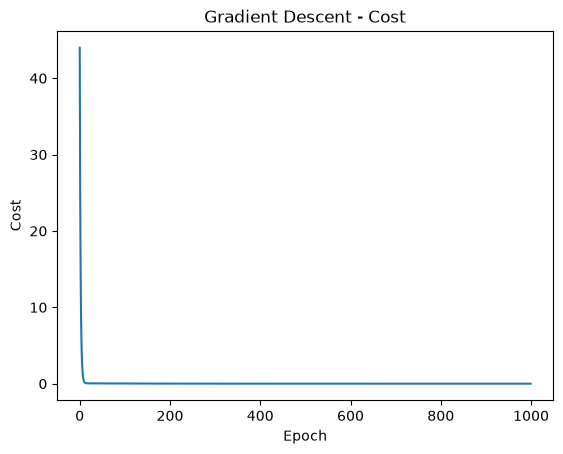

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

# Training data
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)

# Initial parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.01
epochs = 1000
n = len(X)
cost_history = []

for epoch in range(epochs):
    y_pred = w * X + b
    error = y_pred - y
    cost = np.mean(error ** 2)
    cost_history.append(cost)

    dw = (2 / n) * np.sum(X * error)
    db = (2 / n) * np.sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

print("\nFinal parameters:")
print(f"Weight: {w:.4f}")
print(f"Bias: {b:.4f}")

# Test prediction
new_x = 6
prediction = w * new_x + b
print(f"Prediction for x=6: {prediction:.4f}")

# Visualization
x_line = np.linspace(X.min(), X.max(), 200)
y_line = w * x_line + b

df = pd.DataFrame({"X": X, "y": y})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="X", y="y", s=150, color="#1f77b4", edgecolor="black", linewidth=0.7, label="Training data")
sns.lineplot(x=x_line, y=y_line, color="#ff7f0e", linewidth=3, label=f"Fitted line: y = {w:.3f}x + {b:.3f}")
plt.title("Linear Regression from Scratch", fontsize=18, weight="bold")
plt.xlabel("X", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


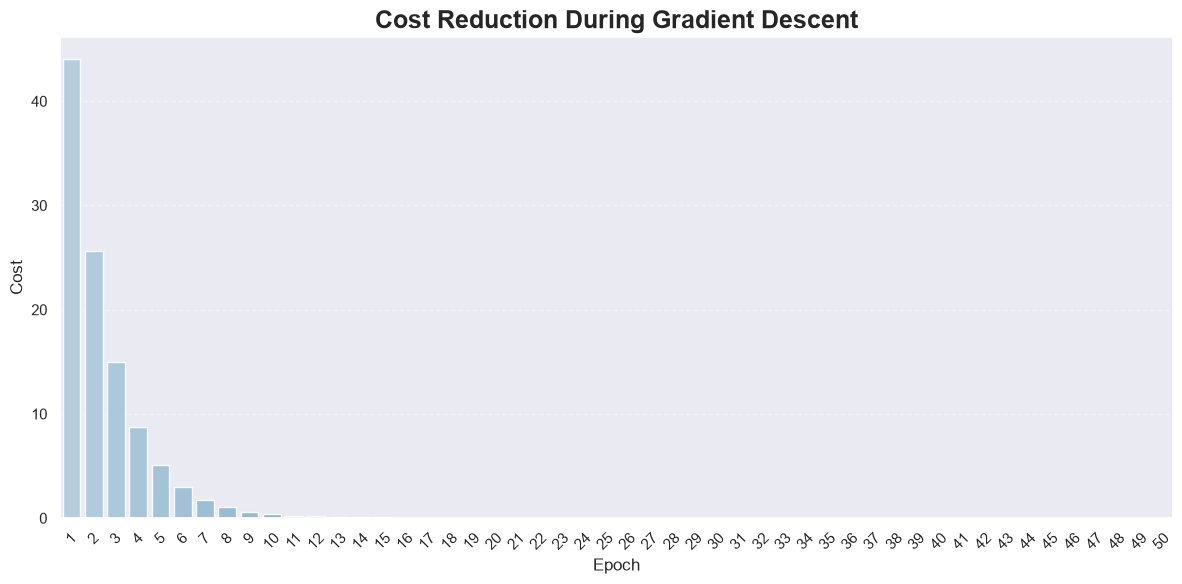

In [7]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)

w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(X)
cost_history = []

for epoch in range(epochs):
    y_pred = w * X + b
    error = y_pred - y
    cost = np.mean(error ** 2)
    cost_history.append(cost)

    dw = (2 / n) * np.sum(X * error)
    db = (2 / n) * np.sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

cost_df = pd.DataFrame({
    "Epoch": np.arange(1, epochs + 1),
    "Cost": cost_history
})

# Show only the first 50 epochs in a bar plot for readability
bar_df = cost_df.head(50).copy()
bar_df["Epoch"] = bar_df["Epoch"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=bar_df, x="Epoch", y="Cost", hue="Epoch", palette="Blues_d", alpha=0.9)
plt.title("Cost Reduction During Gradient Descent", fontsize=18, weight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
%matplotlib inline


| Term             | Easy meaning                             |
| ---------------- | ---------------------------------------- |
| Feature          | Input                                    |
| Label            | Correct answer                           |
| Prediction       | Model's answer                           |
| Weight           | Importance/strength of feature           |
| Bias             | Extra adjustable value                   |
| Cost/Loss        | How wrong model is                       |
| Gradient         | Direction for changing parameters        |
| Gradient Descent | Method for reducing cost                 |
| Learning Rate    | Size of each update                      |
| Epoch            | Training cycle                           |
| Parameter        | Learned value such as `w` or `b`         |
| Hyperparameter   | Setting chosen by us, e.g. learning rate |
